In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose  import  ColumnTransformer 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [51]:
students=pd.read_csv('data_files/student_performance.csv')
df=students.drop('grade',axis=1)
students

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A
...,...,...,...,...,...,...
999995,999996,18.0,95.5,4.8,100.0,A
999996,999997,15.7,82.7,6.7,88.3,A
999997,999998,14.2,85.1,5.8,87.9,A
999998,999999,25.3,90.0,5.3,100.0,A


In [52]:
corr_matrix = students.corr(numeric_only=True)
corr_matrix["total_score"].sort_values(ascending=False)

total_score                1.000000
weekly_self_study_hours    0.812241
class_participation        0.000684
student_id                -0.000492
attendance_percentage     -0.001014
Name: total_score, dtype: float64

In [53]:
df.describe()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,15.029127,84.711046,5.985203,84.283845
std,288675.278933,6.899431,9.424143,1.956421,15.432969
min,1.000000,0.000000,50.000000,0.000000,9.400000
25%,250000.750000,10.300000,78.300000,4.700000,73.900000
50%,500000.500000,15.000000,85.000000,6.000000,87.500000
75%,750000.250000,19.700000,91.800000,7.300000,100.000000
max,1000000.000000,40.000000,100.000000,10.000000,100.000000


In [54]:
df['Weekly_study_cat']=pd.qcut(
    df['weekly_self_study_hours'],
    q=6,
    labels=[1,2,3,4,5,6]
)
df['Weekly_study_cat'].value_counts()

Weekly_study_cat
2    169613
1    167850
5    167727
3    165812
4    165467
6    163531
Name: count, dtype: int64

In [55]:
split = StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_index, test_index in split.split(df,df['Weekly_study_cat']):
    strat_train_set = df.loc[train_index].drop('Weekly_study_cat',axis=1)
    strat_test_set = df.loc[test_index].drop('Weekly_study_cat',axis=1)

In [56]:
std=strat_train_set.copy()
std_labels = std['total_score'].copy()
std_features = std.drop(['total_score','student_id'],axis=1)
std


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
311863,311864,4.4,74.5,5.7,45.1
542346,542347,23.4,85.2,4.2,98.8
929558,929559,14.9,85.2,7.8,77.9
914990,914991,10.9,74.3,6.0,80.7
12699,12700,11.3,76.5,7.5,75.1
...,...,...,...,...,...
935195,935196,6.8,83.8,7.5,74.6
782249,782250,9.5,71.7,5.8,80.3
674083,674084,8.0,82.9,0.3,64.2
944814,944815,16.5,100.0,6.0,100.0


In [57]:
num_attribs=['weekly_self_study_hours', 'attendance_percentage', 'class_participation']
num_pipeline = Pipeline([
    ('Imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

In [58]:
full_pipeline = ColumnTransformer([
    ('num',num_pipeline, num_attribs)
])
std_prepared = full_pipeline.fit_transform(std_features)

In [59]:
rfg=RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)
rfg.fit(std_prepared,std_labels)
rfg_preds = rfg.predict(std_prepared)

In [60]:
std_labels_test = strat_test_set['total_score'].copy()
std_features_test = strat_test_set.drop(['total_score', 'student_id'], axis=1)
std_prepared_test = full_pipeline.transform(std_features_test)
test_preds = rfg.predict(std_prepared_test)
 

In [61]:
mae = mean_absolute_error(std_labels_test, test_preds)
mse = mean_squared_error(std_labels_test, test_preds)
rmse = np.sqrt(mse)
r2 = r2_score(std_labels_test, test_preds)

print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

MAE  : 6.119
MSE  : 67.623
RMSE : 8.223
R²   : 0.716


In [62]:
# testing the overfitting of model
train_preds = rfg.predict(std_prepared)

print("Train R²:", r2_score(std_labels, train_preds))
print("Test  R²:", r2_score(std_labels_test, test_preds))

Train R²: 0.7200692028472717
Test  R²: 0.7162611020280715


In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Check for mismatch first
print("num_attribs count:", len(num_attribs))
print("feature_importances_ count:", len(rfg.feature_importances_))

feature_importance = pd.DataFrame({
    "Feature": num_attribs,
    "Importance": rfg.feature_importances_
})

print(feature_importance)  # sanity check — make sure values are non-zero

num_attribs count: 3
feature_importances_ count: 3
                   Feature  Importance
0  weekly_self_study_hours    0.996567
1    attendance_percentage    0.001962
2      class_participation    0.001471


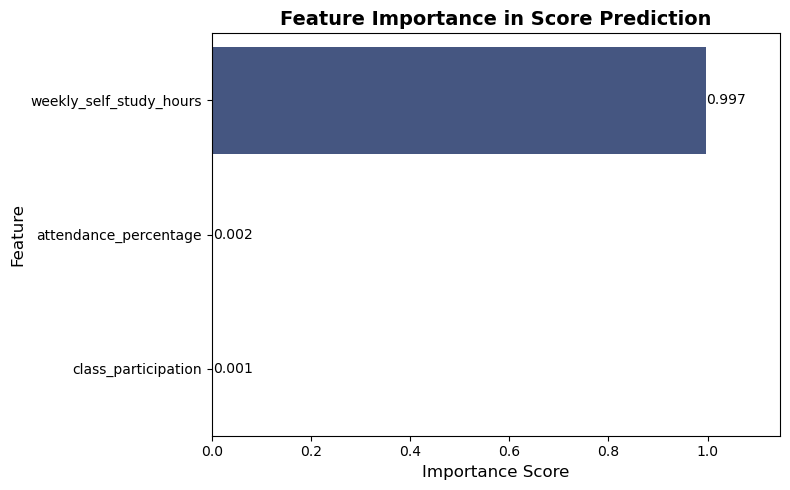

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.DataFrame({
    "Feature": num_attribs,
    "Importance": rfg.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",        # fixes the deprecation warning
    legend=False,         # hides the redundant legend
    order=feature_importance["Feature"],
    palette="viridis"
)

# Add value labels on each bar
for i, v in enumerate(feature_importance["Importance"]):
    plt.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=10)

plt.title("Feature Importance in Score Prediction", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.xlim(0, feature_importance["Importance"].max() * 1.15)

plt.tight_layout()
plt.show()

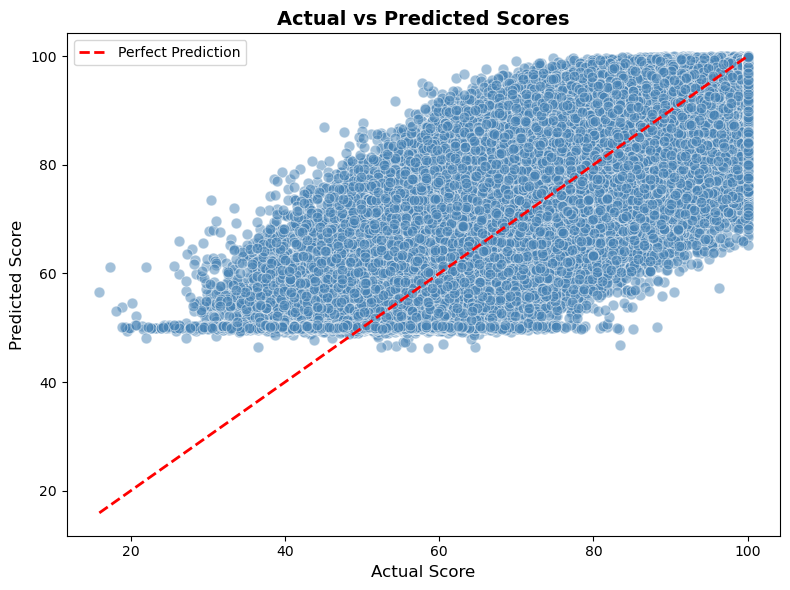

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=std_labels_test,
    y=test_preds,
    alpha=0.5,
    color="steelblue",
    edgecolor="white",
    s=60
)

# Perfect prediction line
plt.plot(
    [std_labels_test.min(), std_labels_test.max()],
    [std_labels_test.min(), std_labels_test.max()],
    'r--',
    linewidth=2,
    label="Perfect Prediction"
)

plt.title("Actual vs Predicted Scores", fontsize=14, fontweight="bold")
plt.xlabel("Actual Score", fontsize=12)
plt.ylabel("Predicted Score", fontsize=12)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

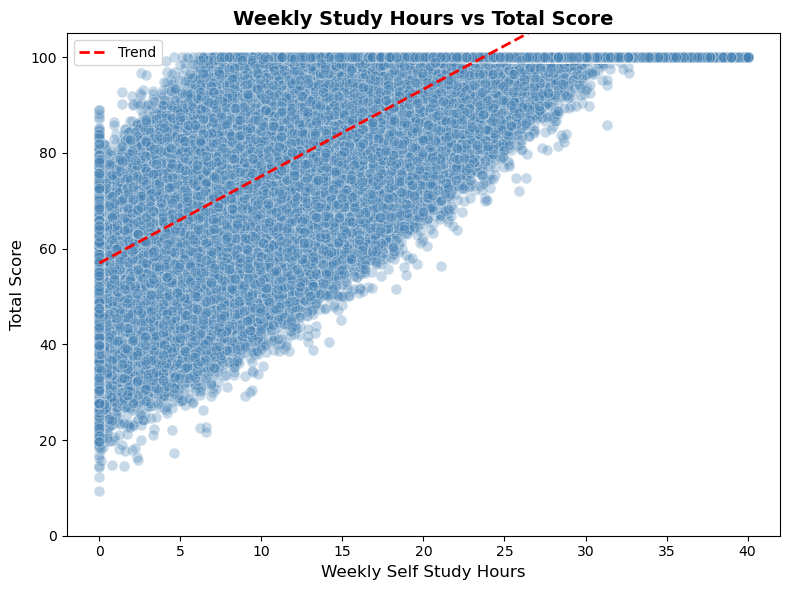

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=students,
    x="weekly_self_study_hours",
    y="total_score",
    alpha=0.3,
    color="steelblue",
    edgecolor="white",
    s=60
)

sns.regplot(
    data=students,
    x="weekly_self_study_hours",
    y="total_score",
    scatter=False,
    color="red",
    truncate=True,          # fixes line going beyond data range
    line_kws={"linewidth": 2, "linestyle": "--"}
)

# Fix legend to show line instead of dot
legend_handle = Line2D([0], [0], color="red", linewidth=2, linestyle="--", label="Trend")
plt.legend(handles=[legend_handle], fontsize=10, loc="upper left")

plt.ylim(0, 105)            # cap y-axis at just above 100
plt.title("Weekly Study Hours vs Total Score", fontsize=14, fontweight="bold")
plt.xlabel("Weekly Self Study Hours", fontsize=12)
plt.ylabel("Total Score", fontsize=12)

plt.tight_layout()
plt.show()
